<a href="https://colab.research.google.com/github/saGit1990/MultiModal-RAG/blob/main/multimodel%20RAG%20CLIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

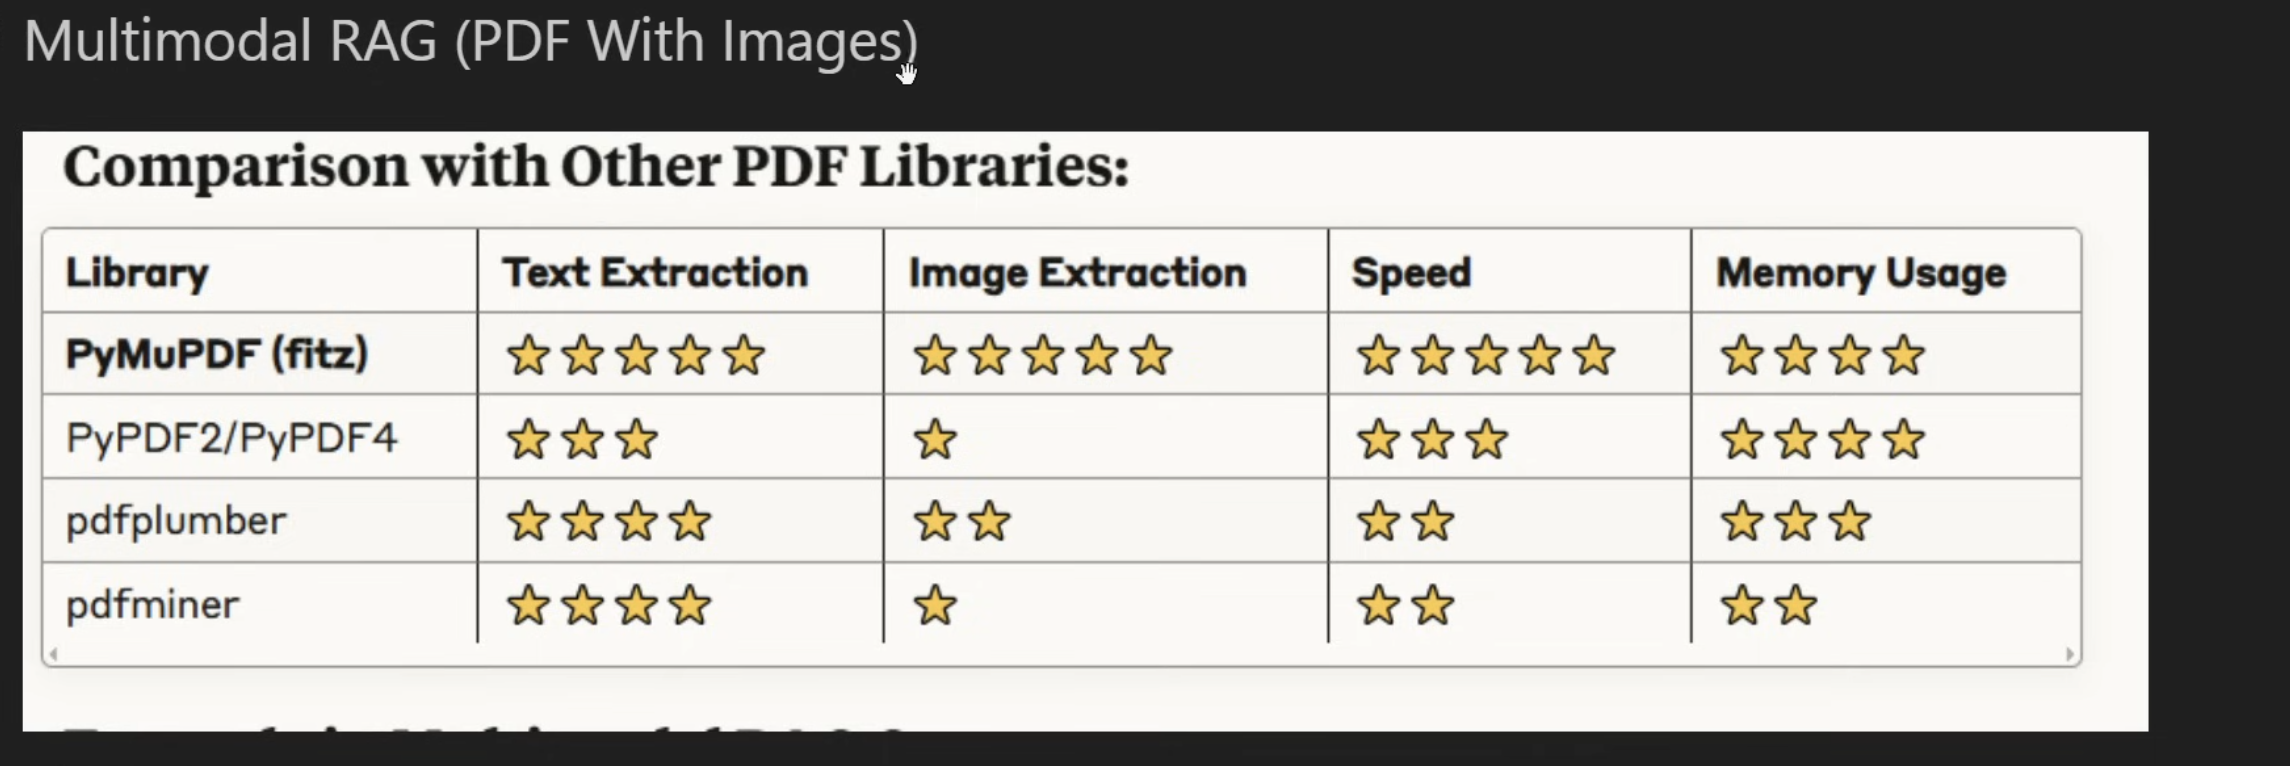

In [3]:
%pip install PyMuPDF
%pip install langchain
%pip install langchain_community
%pip install groq langchain_groq
%pip install faiss-cpu
%pip install langchain-classic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.0 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 69.0 MB/s eta 0:00:00


In [4]:
import fitz
from langchain_core.documents import Document
from transformers import CLIPProcessor, CLIPModel
from PIL import Image

import torch
import numpy as np

from langchain_community.chat_models import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import HumanMessage
from sklearn.metrics.pairwise import cosine_similarity
from langchain_classic.chains import RetrievalQA

import os
import base64
import io

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

In [5]:
from google.colab import userdata

In [6]:
from langchain_groq import ChatGroq

def setup_api_key_for_llm_model(groq_api_key):
    os.environ["GROQ_API_KEY"] = groq_api_key
    llm = ChatGroq(temperature=0, model_name="mixtral-8x7b-32768")
    return llm

groq_api_key = userdata.get('GROQ_API_KEY')
if not groq_api_key:
    raise ValueError("GROQ_API_KEY environment variable not set. Please provide your Groq API key.")

llm_model = setup_api_key_for_llm_model(groq_api_key)
llm_model

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 128, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': False}, client=<groq.resources.chat.completions.Completions object at 0x78eeb0b2cfb0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x78eeb0b50200>, model_name='meta-llama/llama-guard-4-12b', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:
clip_model  = CLIPModel.from_pretrained('openai/clip-vit-base-patch32')
clip_processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [9]:
# embedding functions
def embed_image(image_data):
  if isinstance(image_data, str):
    image = Image.open(image_data).convert('RGB')
  else:
    image = image_data

  inputs = clip_processor(images=image, return_tensors = 'pt')
  with torch.no_grad():
    features = clip_model.get_image_features(**inputs)

    # normalize
    features = features / features.norm(dim=-1, keepdim = True)
    return features.squeeze().numpy()


def embed_text(text):
  inputs = clip_processor(
        text=text,
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=77 # clips max token length
    )

  with torch.no_grad():
    features = clip_model.get_text_features(**inputs)

    # normalize
    features = features / features.norm(dim=-1, keepdim = True)
    return features.squeeze().numpy()

In [11]:
## process pdf
pdf_path = '/content/attention is all you need.pdf'
doc = fitz.open(pdf_path)

# storage for all documents and embeddings
all_docs = []
all_embeddings = []
image_data_store = {}

splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100
)
doc

Document('/content/attention is all you need.pdf')

In [12]:
for i, page in enumerate(doc):
  # process text
  text = page.get_text()
  if text.strip():
    # create temp doc for splitting
    temp_doc = Document(page_content=text, metadata={'page':i, "type":'text'})
    text_chunk = splitter.split_documents([temp_doc])

    # embed each chunk
    for chunk in text_chunk:
      embedding = embed_text([chunk.page_content])
      all_embeddings.append(embedding)
      all_docs.append(chunk)

In [13]:
# process images
for i, page in enumerate(doc):

  ## 3 actions
  ### 1. Convert PDF to PIL format
  ### 2. Store as base64
  ### 3. create CLIP embedding for retrieval
    for img_index, img in enumerate(page.get_images(full=True)):
      try:
        xref = img[0]
        base_image = doc.extract_image(xref)
        image_bytes = base_image['image']

        # convert to PIL image
        pil_image = Image.open(io.BytesIO(image_bytes)).convert('RGB')

        image_id = f'page_{i}_img_{img_index}'

        # store image as base64 for later use
        buffered = io.BytesIO()
        pil_image.save(buffered,format='PNG')
        img_base64 = base64.b64encode(buffered.getvalue()).decode()
        image_data_store[image_id] = img_base64

        # embed image
        embedding = embed_image(pil_image)
        all_embeddings.append(embedding)

        image_doc = Document(
            page_content = f"[image: {image_id}]",
            metadata={"page": i, "type":"image","image_id":image_id}
        )
        all_docs.append(image_doc)

      except Exception as e:
        print(f'Error processing image {img_index} on page {i}: {e}')
        continue

In [14]:
embedding_array = np.array(all_embeddings)

In [20]:
# create FIASS

vdb = FAISS.from_embeddings(
    text_embeddings = [(doc.page_content, emb) for doc, emb in zip(all_docs, embedding_array)],
    embedding = embed_text ,
    metadatas = [doc.metadata for doc in all_docs]
    )

In [31]:
all_docs[40]

Document(metadata={'page': 5, 'type': 'text'}, page_content='O(n · d2)\nO(n)\nO(n)\nConvolutional\nO(k · n · d2)\nO(1)\nO(logk(n))\nSelf-Attention (restricted)\nO(r · n · d)\nO(1)\nO(n/r)\nbottoms of the encoder and decoder stacks. The positional encodings have the same dimension dmodel\nas the embeddings, so that the two can be summed. There are many choices of positional encodings,\nlearned and ﬁxed [8].\nIn this work, we use sine and cosine functions of different frequencies:\nPE(pos,2i) = sin(pos/100002i/dmodel)\nPE(pos,2i+1) = cos(pos/100002i/dmodel)')

In [40]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

rag_prompt = PromptTemplate(
    template="""You are an assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question.
If you don't know the answer, just say that you don't know.
Keep the answer concise.

Question: {question}
Context: {context}

Answer:""",
    input_variables=["question", "context"],
)


In [41]:

retriever = vdb.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5}
)

rag_chain = (
    {
        "context": retriever,
        "question": RunnablePassthrough(),
    }
    | rag_prompt
    | llm_model
    | StrOutputParser()
)


In [43]:
question = "what is attention?"
docs = retriever.invoke(question)

print(len(docs))
for i, d in enumerate(docs):
    print(f"\n--- doc {i} ---")
    print(d.page_content[:300])


5

--- doc 0 ---
6

--- doc 1 ---
described in section 3.2.
Self-attention, sometimes called intra-attention is an attention mechanism relating different positions
of a single sequence in order to compute a representation of the sequence. Self-attention has been
used successfully in a variety of tasks including reading comprehension

--- doc 2 ---
base
6
512
2048
8
64
64
0.1
0.1
100K
4.92
25.8
65
(A)
1
512
512
5.29
24.9
4
128
128
5.00
25.5
16
32
32
4.91
25.8
32
16
16
5.01
25.4
(B)
16
5.16
25.1
58
32
5.01
25.4
60
(C)
2
6.11
23.7
36
4
5.19
25.3
50
8
4.88
25.5
80
256
32
32
5.75
24.5
28
1024
128
128
4.66
26.0
168
1024
5.12
25.4
53
4096
4.75
26.2


--- doc 3 ---
in particular, have been ﬁrmly established as state of the art approaches in sequence modeling and
transduction problems such as language modeling and machine translation [29, 2, 5]. Numerous
efforts have since continued to push the boundaries of recurrent language models and encoder-decoder
archite

--- doc 4 ---
the approach we ta

In [42]:
# Initialize the RAG chain
## Questions 1
question = "what is attention?"
answer = rag_chain.invoke(question)
print(answer)



safe


In [24]:
# Question 2
question2 = "summarise this doc?"
response2 = rag_chain.invoke(question2)
print(f"Question 2: {question2}")
print(f"Answer 2: {response2['result']}")

Question 2: summarise this doc?
Answer 2: unsafe
S8


In [25]:
# Question 2
question2 = "Explain the attention architecture image?"
response2 = rag_chain.invoke(question2)
print(f"Question 2: {question2}")
print(f"Answer 2: {response2['result']}")

Question 2: Explain the attention architecture image?
Answer 2: safe
